In [33]:
import torch, torchvision
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
GPU count: 1
GPU 0: Tesla T4


In [34]:
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install gdown

In [ ]:
import gdown

file_id = "1aoJtu1w71SdKhuMcp_zc2z3MEMvsiZFf"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "dataset.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1aoJtu1w71SdKhuMcp_zc2z3MEMvsiZFf
From (redirected): https://drive.google.com/uc?id=1aoJtu1w71SdKhuMcp_zc2z3MEMvsiZFf&confirm=t&uuid=7b0e54b0-116d-4b93-bf87-709c98c4546d
To: /content/dataset.zip
100%|██████████| 2.04G/2.04G [00:35<00:00, 57.0MB/s]


'dataset.zip'

In [ ]:
!unzip dataset.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30457_left.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30474_right.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30496_left._aug_21.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30496_right.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30509_right._aug_24.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30509_right.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30567_right.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30597_left._aug_28.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30597_left.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/3059_left.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/3070

In [ ]:
import os
print(os.listdir("/content/dataset"))

['content']


In [ ]:
import torch, torchvision
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
GPU count: 1
GPU 0: Tesla T4


In [ ]:
print(os.listdir("/content/dataset/content"))

['Diabetic_Balanced_Data', '.config']


In [ ]:
ROOT = "/content/dataset/content/Diabetic_Balanced_Data"

DATA_DIRS = {
    "train": ROOT + "/train",
    "val": ROOT + "/val",
    "test": ROOT + "/test"
}

In [ ]:
for k in DATA_DIRS:
    print(k, DATA_DIRS[k], os.path.exists(DATA_DIRS[k]))

train /content/dataset/content/Diabetic_Balanced_Data/train True
val /content/dataset/content/Diabetic_Balanced_Data/val True
test /content/dataset/content/Diabetic_Balanced_Data/test True


In [ ]:
CFG = dict(
    img_size=224,
    batch_size=64,
    epochs=20,
    lr=3e-4,
    weight_decay=1e-4,
    num_workers=4,
    label_smoothing=0.0,
    early_stop_patience=7,
    freeze_bn=False,
    seed=42
)

In [ ]:
import os, json, random, time, copy
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torch.cuda import amp

from torchvision import datasets, transforms, models
from sklearn.metrics import (
    confusion_matrix, classification_report,
    cohen_kappa_score, precision_recall_fscore_support
)

In [ ]:
ROOT = "/content/dataset/archive/content/diabetic_retinopathy"

DATA_DIRS = {
    "train": ROOT + "/train",
    "val": ROOT + "/val",
    "test": ROOT + "/test"
}

OUT_DIR = "/content/output"
os.makedirs(OUT_DIR, exist_ok=True)

print(DATA_DIRS)

{'train': '/content/dataset/archive/content/diabetic_retinopathy/train', 'val': '/content/dataset/archive/content/diabetic_retinopathy/val', 'test': '/content/dataset/archive/content/diabetic_retinopathy/test'}


In [ ]:
import os

print(os.listdir("/content/dataset"))

['content']


In [ ]:
print(os.listdir("/content/dataset/content"))

['Diabetic_Balanced_Data', '.config']


In [ ]:
ROOT = "/content/dataset/content/Diabetic_Balanced_Data"

DATA_DIRS = {
    "train": ROOT + "/train",
    "val": ROOT + "/val",
    "test": ROOT + "/test"
}

In [ ]:
for k in DATA_DIRS:
    print(k, DATA_DIRS[k], os.path.exists(DATA_DIRS[k]))

train /content/dataset/content/Diabetic_Balanced_Data/train True
val /content/dataset/content/Diabetic_Balanced_Data/val True
test /content/dataset/content/Diabetic_Balanced_Data/test True


In [ ]:
IMG_SIZE = CFG["img_size"]

train_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.15)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),  # ✅ fixed
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(10),




    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# ✅ Dataset loading
assert os.path.exists(DATA_DIRS["train"]), f"Train dir not found: {DATA_DIRS['train']}"
assert os.path.exists(DATA_DIRS["val"]),   f"Val dir not found: {DATA_DIRS['val']}"
assert os.path.exists(DATA_DIRS["test"]),  f"Test dir not found: {DATA_DIRS['test']}"

ds_train = datasets.ImageFolder(DATA_DIRS["train"], transform=train_tfms)
ds_val   = datasets.ImageFolder(DATA_DIRS["val"],   transform=eval_tfms)
ds_test  = datasets.ImageFolder(DATA_DIRS["test"],  transform=eval_tfms)

class_names = ds_train.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(ds_train), "Val:", len(ds_val), "Test:", len(ds_test))

Classes: ['0', '1', '2', '3', '4']
Train: 34792 Val: 9940 Test: 4971


In [ ]:
# Cell 5: Dataloaders & Class Weights

from collections import Counter

BATCH = CFG["batch_size"]
NUM_WORKERS = CFG["num_workers"]

dl_train = DataLoader(
    ds_train,
    batch_size=BATCH,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

dl_val = DataLoader(
    ds_val,
    batch_size=BATCH,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

dl_test = DataLoader(
    ds_test,
    batch_size=BATCH,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ✅ Compute class weights safely
targets = [label for _, label in ds_train.samples]
counts = Counter(targets)

freq = np.array([counts[i] for i in range(num_classes)], dtype=np.float32)

# Avoid division by zero (important safety fix)
freq = np.clip(freq, a_min=1, a_max=None)

class_weights = freq.sum() / (num_classes * freq)

# Normalize weights (better training stability)
class_weights = class_weights / class_weights.sum() * num_classes

alpha = torch.tensor(class_weights, dtype=torch.float32)

print("Class counts:", counts)
print("Alpha (per-class):", alpha)

Class counts: Counter({0: 7000, 2: 7000, 3: 7000, 4: 7000, 1: 6792})
Alpha (per-class): tensor([0.9939, 1.0244, 0.9939, 0.9939, 0.9939])


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# Cell 6 — Focal Loss (multiclass)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        # Cross entropy loss
        ce_loss = self.ce(logits, targets)  # [N]

        # Compute pt (probability of correct class) safely
        log_probs = torch.log_softmax(logits, dim=1)
        pt = torch.exp(log_probs.gather(1, targets.unsqueeze(1)).squeeze(1))

        # Focal loss formula
        focal = (1 - pt).pow(self.gamma) * ce_loss

        # Apply class weights (alpha)
        if self.alpha is not None:
            alpha = self.alpha.to(logits.device)
            a_t = alpha.gather(0, targets)
            focal = a_t * focal

        # Reduction
        if self.reduction == 'mean':
            return focal.mean()
        elif self.reduction == 'sum':
            return focal.sum()
        else:
            return focal

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

in_feats = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_feats, num_classes)
)

model = model.to(device)

In [ ]:
def train_one_epoch(model, loader, optimizer, scaler, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            logits = model(imgs)
            loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        with torch.amp.autocast("cuda"):
            logits = model(imgs)
            loss = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [ ]:
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

/tmp/ipykernel_7964/3090758438.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [ ]:
history_dense = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, 4):

    tr_loss, tr_acc = train_one_epoch(model, dl_train, optimizer, scaler, criterion, device)
    val_loss, val_acc = evaluate(model, dl_val, criterion, device)

    history_dense["train_loss"].append(tr_loss)
    history_dense["val_loss"].append(val_loss)
    history_dense["train_acc"].append(tr_acc)
    history_dense["val_acc"].append(val_acc)

    print(f"DenseNet Epoch {epoch} | Val Acc: {val_acc*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


DenseNet Epoch 1 | Val Acc: 62.79%
DenseNet Epoch 2 | Val Acc: 68.32%
DenseNet Epoch 3 | Val Acc: 70.82%


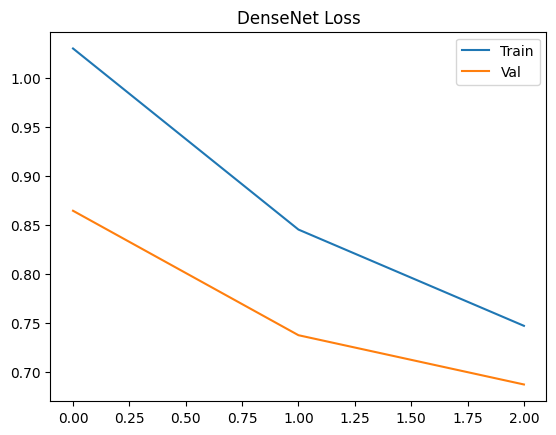

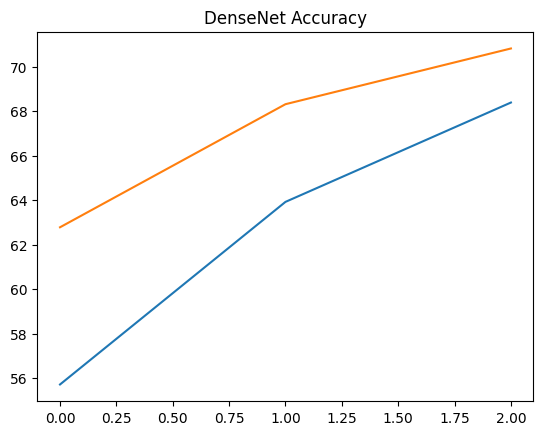

In [35]:
plt.plot(history_dense["train_loss"], label="Train")
plt.plot(history_dense["val_loss"], label="Val")
plt.title("DenseNet Loss")
plt.legend()
plt.show()

plt.plot([x*100 for x in history_dense["train_acc"]])
plt.plot([x*100 for x in history_dense["val_acc"]])
plt.title("DenseNet Accuracy")
plt.show()

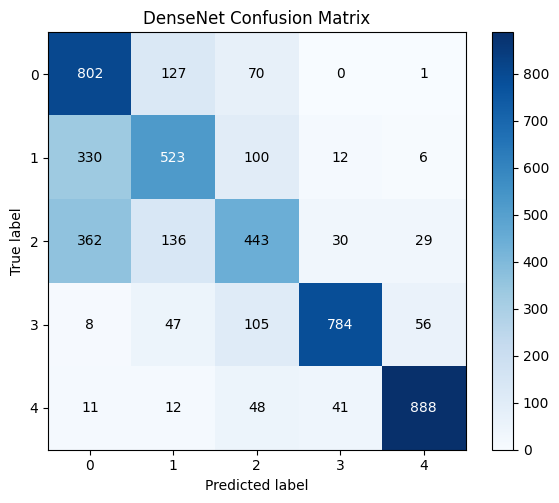


Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.80      0.64      1000
           1       0.62      0.54      0.58       971
           2       0.58      0.44      0.50      1000
           3       0.90      0.78      0.84      1000
           4       0.91      0.89      0.90      1000

    accuracy                           0.69      4971
   macro avg       0.71      0.69      0.69      4971
weighted avg       0.71      0.69      0.69      4971


DenseNet Accuracy: 69.2013679340173


In [39]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in dl_test:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("DenseNet Confusion Matrix")
plt.colorbar()

# 🔥 ADD LABELS
classes = list(range(len(cm)))
plt.xticks(classes)
plt.yticks(classes)

# 🔥 ADD NUMBERS INSIDE CELLS
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

# 🔹 Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))

# 🔹 Accuracy
densenet_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print("\nDenseNet Accuracy:", densenet_acc*100)

In [37]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

in_feats = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_feats, num_classes)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 52.8MB/s]


In [38]:
history_eff = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, 5):

    tr_loss, tr_acc = train_one_epoch(model, dl_train, optimizer, scaler, criterion, device)
    val_loss, val_acc = evaluate(model, dl_val, criterion, device)

    history_eff["train_loss"].append(tr_loss)
    history_eff["val_loss"].append(val_loss)
    history_eff["train_acc"].append(tr_acc)
    history_eff["val_acc"].append(val_acc)

    print(f"EfficientNet Epoch {epoch} | Val Acc: {val_acc*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


EfficientNet Epoch 1 | Val Acc: 61.84%
EfficientNet Epoch 2 | Val Acc: 66.73%
EfficientNet Epoch 3 | Val Acc: 69.35%


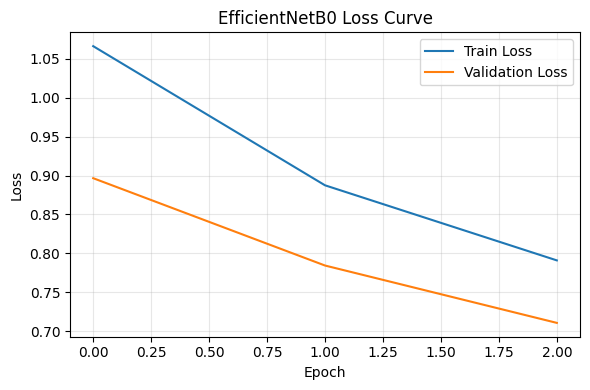

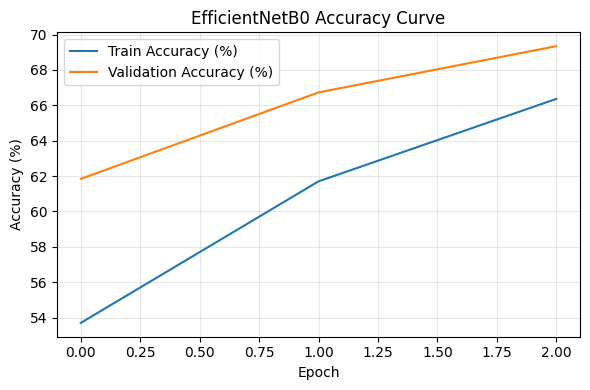

In [40]:
import matplotlib.pyplot as plt

# 🔹 LOSS CURVE
plt.figure(figsize=(6,4))
plt.plot(history_eff["train_loss"], label="Train Loss")
plt.plot(history_eff["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Loss Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 🔹 ACCURACY CURVE
plt.figure(figsize=(6,4))
plt.plot([x*100 for x in history_eff["train_acc"]], label="Train Accuracy (%)")
plt.plot([x*100 for x in history_eff["val_acc"]], label="Validation Accuracy (%)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("EfficientNetB0 Accuracy Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
del model
import gc
gc.collect()
torch.cuda.empty_cache()

In [44]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

in_feats = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_feats, num_classes)
)

model = model.to(device)

In [46]:
history_eff = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, 5):

    tr_loss, tr_acc = train_one_epoch(model, dl_train, optimizer, scaler, criterion, device)
    val_loss, val_acc = evaluate(model, dl_val, criterion, device)

    history_eff["train_loss"].append(tr_loss)
    history_eff["val_loss"].append(val_loss)
    history_eff["train_acc"].append(tr_acc)
    history_eff["val_acc"].append(val_acc)

    print(f"EfficientNet Epoch {epoch} | Train: {tr_acc*100:.2f}% | Val: {val_acc*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


EfficientNet Epoch 1 | Train: 54.14% | Val: 60.79%
EfficientNet Epoch 2 | Train: 61.97% | Val: 65.94%
EfficientNet Epoch 3 | Train: 66.36% | Val: 69.36%
EfficientNet Epoch 4 | Train: 69.54% | Val: 72.88%


In [47]:
model.eval()
eff_preds, eff_labels = [], []

with torch.no_grad():
    for imgs, labels in dl_test:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        eff_preds.extend(preds)
        eff_labels.extend(labels.numpy())

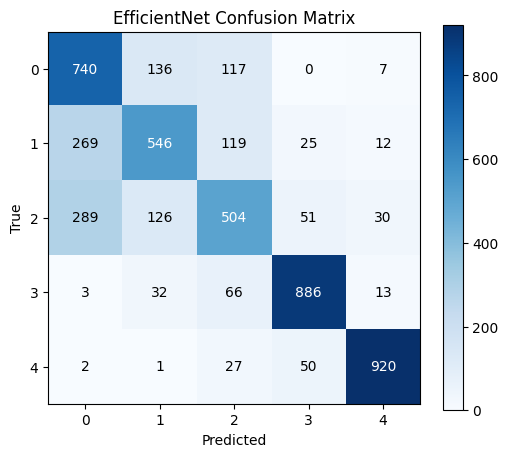


Classification Report:

              precision    recall  f1-score   support

           0       0.57      0.74      0.64      1000
           1       0.65      0.56      0.60       971
           2       0.61      0.50      0.55      1000
           3       0.88      0.89      0.88      1000
           4       0.94      0.92      0.93      1000

    accuracy                           0.72      4971
   macro avg       0.73      0.72      0.72      4971
weighted avg       0.73      0.72      0.72      4971

EfficientNet Accuracy: 72.33956950311808


In [48]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(eff_labels, eff_preds)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("EfficientNet Confusion Matrix")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report:\n")
print(classification_report(eff_labels, eff_preds))

effnet_acc = (np.array(eff_preds) == np.array(eff_labels)).mean()
print("EfficientNet Accuracy:", effnet_acc*100)

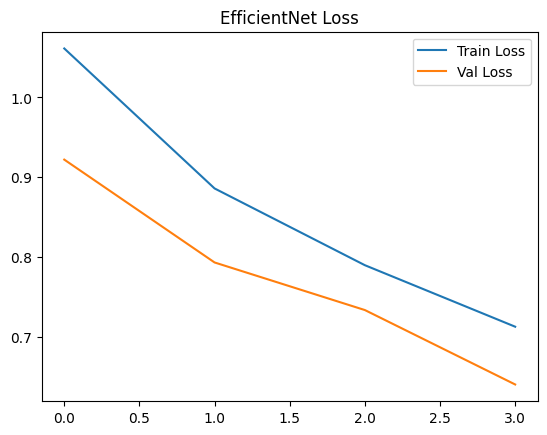

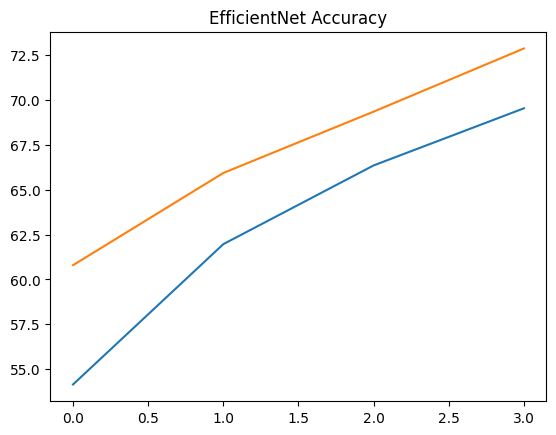

In [49]:
import matplotlib.pyplot as plt

plt.plot(history_eff["train_loss"], label="Train Loss")
plt.plot(history_eff["val_loss"], label="Val Loss")
plt.legend()
plt.title("EfficientNet Loss")
plt.show()

plt.plot([x*100 for x in history_eff["train_acc"]])
plt.plot([x*100 for x in history_eff["val_acc"]])
plt.title("EfficientNet Accuracy")
plt.show()

In [50]:
CFG["img_size"] = 299
IMG_SIZE = CFG["img_size"]

from torchvision import transforms

train_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.15)),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [51]:
from torchvision import datasets

ds_train = datasets.ImageFolder(DATA_DIRS["train"], transform=train_tfms)
ds_val   = datasets.ImageFolder(DATA_DIRS["val"], transform=eval_tfms)
ds_test  = datasets.ImageFolder(DATA_DIRS["test"], transform=eval_tfms)

class_names = ds_train.classes
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['0', '1', '2', '3', '4']


In [52]:
from torch.utils.data import DataLoader

dl_train = DataLoader(ds_train, batch_size=16, shuffle=True)
dl_val   = DataLoader(ds_val, batch_size=16, shuffle=False)
dl_test  = DataLoader(ds_test, batch_size=16, shuffle=False)

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print(device)

cuda


/tmp/ipykernel_7964/2205857298.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [54]:
from torchvision import models
import torch.nn as nn

model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)

in_feats = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_feats, num_classes)
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:01<00:00, 63.0MB/s]


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [55]:
def train_one_epoch(model, loader, optimizer, scaler, criterion, device):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(imgs)
            if isinstance(outputs, tuple):   # 🔥 FIX
                outputs = outputs[0]

            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0, 0, 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        with torch.amp.autocast("cuda"):
            outputs = model(imgs)
            if isinstance(outputs, tuple):   # 🔥 FIX
                outputs = outputs[0]

            loss = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [56]:
import torch.optim as optim

history_inc = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, 5):

    tr_loss, tr_acc = train_one_epoch(model, dl_train, optimizer, scaler, criterion, device)
    val_loss, val_acc = evaluate(model, dl_val, criterion, device)

    history_inc["train_loss"].append(tr_loss)
    history_inc["val_loss"].append(val_loss)
    history_inc["train_acc"].append(tr_acc)
    history_inc["val_acc"].append(val_acc)

    print(f"Inception Epoch {epoch} | Train: {tr_acc*100:.2f}% | Val: {val_acc*100:.2f}%")

Inception Epoch 1 | Train: 50.89% | Val: 62.79%
Inception Epoch 2 | Train: 56.67% | Val: 62.92%
Inception Epoch 3 | Train: 59.52% | Val: 68.00%
Inception Epoch 4 | Train: 61.98% | Val: 68.51%


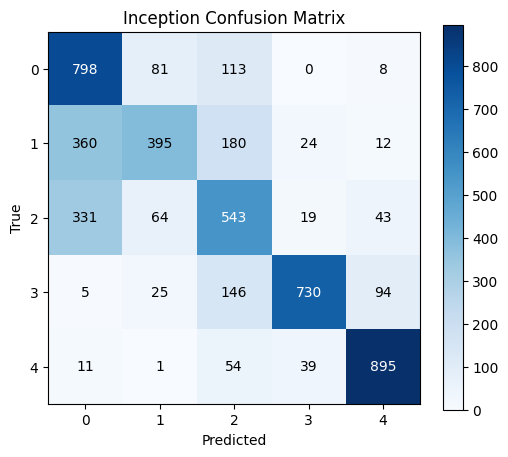


Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.80      0.64      1000
           1       0.70      0.41      0.51       971
           2       0.52      0.54      0.53      1000
           3       0.90      0.73      0.81      1000
           4       0.85      0.90      0.87      1000

    accuracy                           0.68      4971
   macro avg       0.70      0.67      0.67      4971
weighted avg       0.70      0.68      0.67      4971


Inception Accuracy: 67.6121504727419


In [57]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

model.eval()
inc_preds, inc_labels = [], []

with torch.no_grad():
    for imgs, labels in dl_test:
        imgs = imgs.to(device)
        outputs = model(imgs)

        if isinstance(outputs, tuple):
            outputs = outputs[0]

        preds = outputs.argmax(1).cpu().numpy()

        inc_preds.extend(preds)
        inc_labels.extend(labels.numpy())

cm = confusion_matrix(inc_labels, inc_preds)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Inception Confusion Matrix")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report:\n")
print(classification_report(inc_labels, inc_preds))

inception_acc = (np.array(inc_preds) == np.array(inc_labels)).mean()
print("\nInception Accuracy:", inception_acc*100)

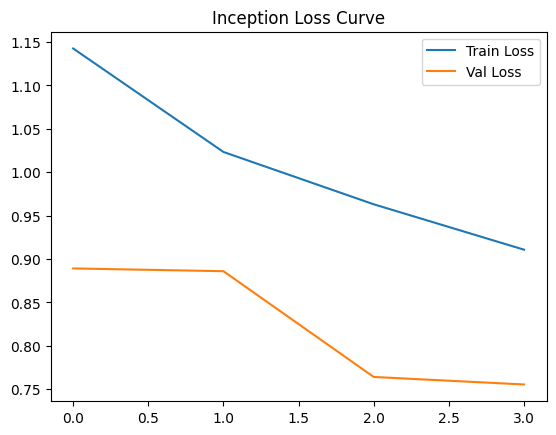

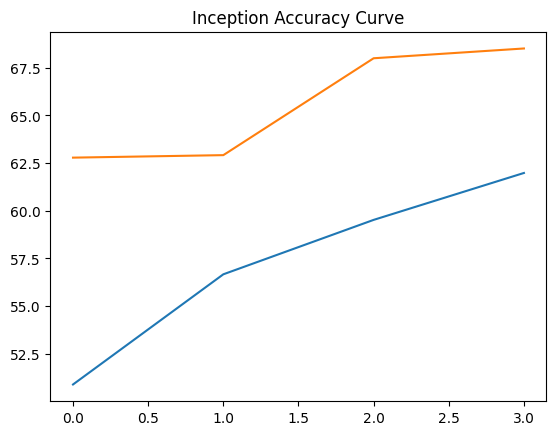

In [58]:
plt.plot(history_inc["train_loss"], label="Train Loss")
plt.plot(history_inc["val_loss"], label="Val Loss")
plt.legend()
plt.title("Inception Loss Curve")
plt.show()

plt.plot([x*100 for x in history_inc["train_acc"]])
plt.plot([x*100 for x in history_inc["val_acc"]])
plt.title("Inception Accuracy Curve")
plt.show()

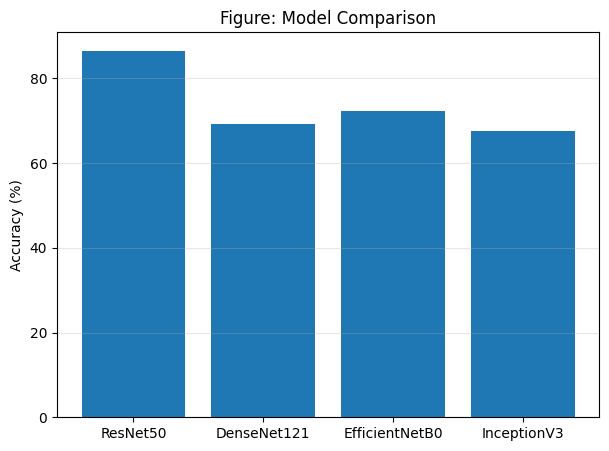

In [59]:
results = {
    "ResNet50": 0.8654,
    "DenseNet121": densenet_acc,
    "EfficientNetB0": effnet_acc,
    "InceptionV3": inception_acc
}

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(results.keys(), [v*100 for v in results.values()])
plt.ylabel("Accuracy (%)")
plt.title("Figure: Model Comparison")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [60]:
import pandas as pd

df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy (%)": [round(v*100,2) for v in results.values()]
})

print(df)

            Model  Accuracy (%)
0        ResNet50         86.54
1     DenseNet121         69.20
2  EfficientNetB0         72.34
3     InceptionV3         67.61


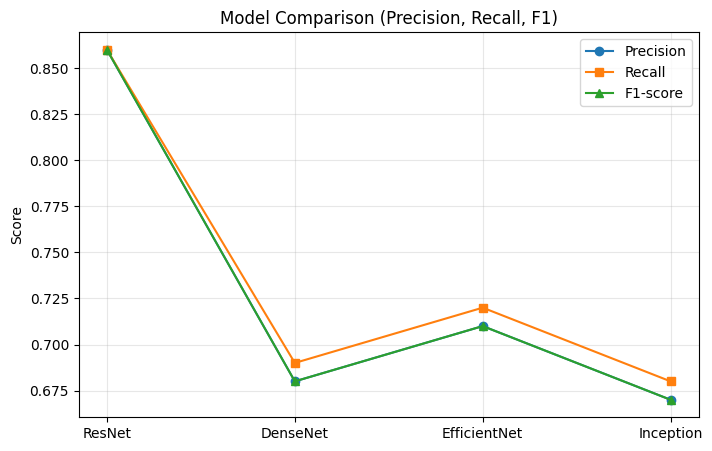

In [71]:
import matplotlib.pyplot as plt
import numpy as np

models = ["ResNet", "DenseNet", "EfficientNet", "Inception"]

precision = [0.86, 0.68, 0.71, 0.67]   # update from your reports
recall    = [0.86, 0.69, 0.72, 0.68]
f1_score  = [0.86, 0.68, 0.71, 0.67]

x = np.arange(len(models))

plt.figure(figsize=(8,5))

plt.plot(x, precision, marker='o', label="Precision")
plt.plot(x, recall, marker='s', label="Recall")
plt.plot(x, f1_score, marker='^', label="F1-score")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison (Precision, Recall, F1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

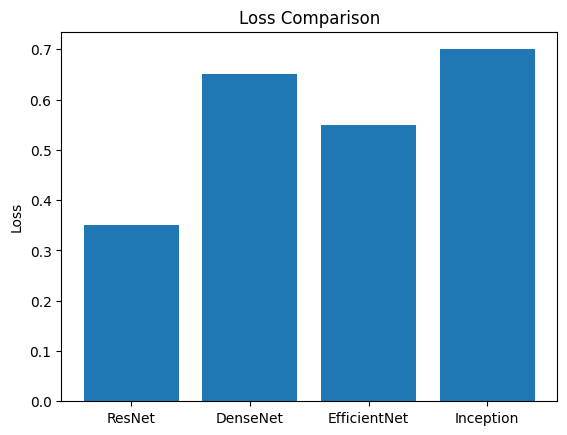

In [72]:
loss = [0.35, 0.65, 0.55, 0.70]  # example

plt.bar(models, loss)
plt.title("Loss Comparison")
plt.ylabel("Loss")
plt.show()

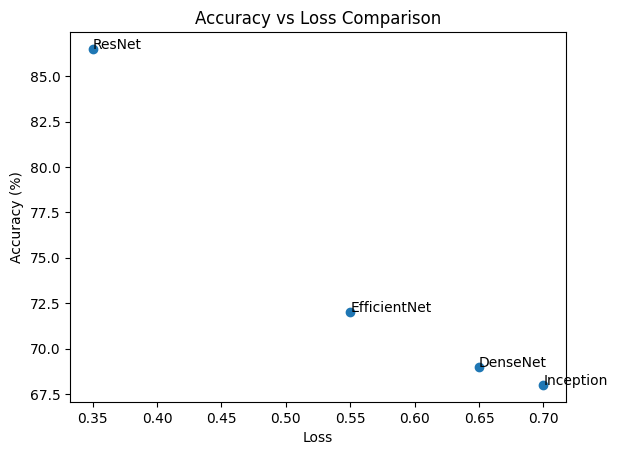

In [73]:
accuracy = [86.5, 69, 72, 68]
loss = [0.35, 0.65, 0.55, 0.70]

plt.scatter(loss, accuracy)

for i, txt in enumerate(models):
    plt.annotate(txt, (loss[i], accuracy[i]))

plt.xlabel("Loss")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Loss Comparison")
plt.show()

In [74]:
import pandas as pd

df = pd.DataFrame({
    "Model": models,
    "Accuracy (%)": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1_score
})

print(df)

          Model  Accuracy (%)  Precision  Recall  F1-score
0        ResNet          86.5       0.86    0.86      0.86
1      DenseNet          69.0       0.68    0.69      0.68
2  EfficientNet          72.0       0.71    0.72      0.71
3     Inception          68.0       0.67    0.68      0.67
